In [25]:
import torch
import sys

print("="*60)
print("DIAGNOSTYKA SRODOWISKA - Google Colab")
print("="*60)

print(f"\nPython: {sys.version}")
print(f"PyTorch: {torch.__version__}")

print("\nGPU:")
if torch.cuda.is_available():
    print(f"   CUDA dostepne")
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   Ilosc GPU: {torch.cuda.device_count()}")

    print("\nTest obliczen na GPU:")
    a = torch.tensor([[1.0, 2.0], [3.0, 4.0]], device='cuda')
    b = torch.tensor([[1.0, 1.0], [0.0, 1.0]], device='cuda')
    c = torch.matmul(a, b)
    print(f"   GPU dziala! Wynik: {c.cpu().numpy()}")

    print(f"\nPamiec GPU:")
    print(f"   Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   Wolna: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB zarezerwowane")
else:
    print("   CUDA niedostepne!")
    print("   Wlacz GPU: Runtime -> Change runtime type -> GPU")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {DEVICE}")
print("="*60)

DIAGNOSTYKA SRODOWISKA - Google Colab

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch: 2.9.0+cu126

GPU:
   CUDA dostepne
   GPU: Tesla T4
   CUDA version: 12.6
   Ilosc GPU: 1

Test obliczen na GPU:
   GPU dziala! Wynik: [[1. 3.]
 [3. 7.]]

Pamiec GPU:
   Total: 15.8 GB
   Wolna: 2.0 GB zarezerwowane

Device: cuda


In [26]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive', force_remount=True)

ZIP_PATH = '/content/drive/MyDrive/INZYNIERKA/DATA/split.zip'

if os.path.exists(ZIP_PATH):
    print(f"Znaleziono: {ZIP_PATH}")
    print("Rozpakowywanie... (moze potrwac kilka minut)")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Gotowe!")
    print("\nStruktura /content/:")
    !ls -la /content/
    print("\nStruktura /content/split/:")
    !ls -la /content/split/
else:
    print(f"Nie znaleziono: {ZIP_PATH}")
    print("\nSprawdz czy plik istnieje:")
    !ls -la "/content/drive/MyDrive/INZYNIERKA/DATA/" 2>/dev/null || echo "Folder nie istnieje"

Mounted at /content/drive
Znaleziono: /content/drive/MyDrive/INZYNIERKA/DATA/split.zip
Rozpakowywanie... (moze potrwac kilka minut)
Gotowe!

Struktura /content/:
total 24
drwxr-xr-x 1 root root 4096 Dec 29 23:36 .
drwxr-xr-x 1 root root 4096 Dec 29 19:44 ..
drwxr-xr-x 4 root root 4096 Dec  9 14:41 .config
drwx------ 5 root root 4096 Dec 29 23:36 drive
drwxr-xr-x 1 root root 4096 Dec  9 14:42 sample_data
drwxr-xr-x 5 root root 4096 Dec 29 19:46 split

Struktura /content/split/:
total 20
drwxr-xr-x 5 root root 4096 Dec 29 19:46 .
drwxr-xr-x 1 root root 4096 Dec 29 23:36 ..
drwxr-xr-x 4 root root 4096 Dec 29 19:46 test
drwxr-xr-x 4 root root 4096 Dec 29 19:46 train
drwxr-xr-x 4 root root 4096 Dec 29 19:45 val


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling"""
    def __init__(self, in_channels, out_channels=256):
        super().__init__()

        # 1x1 conv
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        # 3x3 conv z różnymi dilation rates
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=6, dilation=6, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=18, dilation=18, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        # Global Average Pooling
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        # Projekcja po konkatenacji
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        size = x.shape[2:]

        feat1 = self.conv1(x)
        feat2 = self.conv2(x)
        feat3 = self.conv3(x)
        feat4 = self.conv4(x)
        feat5 = F.interpolate(self.pool(x), size=size, mode='bilinear', align_corners=False)

        return self.project(torch.cat([feat1, feat2, feat3, feat4, feat5], dim=1))


class DeepLabV3Plus(nn.Module):
    """DeepLabV3+ z ResNet50 backbone"""
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()

        # Backbone: ResNet50 (pretrained)
        resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)

        # Encoder layers
        self.layer0 = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool
        )
        self.layer1 = resnet.layer1  # 256 channels, stride 4
        self.layer2 = resnet.layer2  # 512 channels, stride 8
        self.layer3 = resnet.layer3  # 1024 channels, stride 16
        self.layer4 = resnet.layer4  # 2048 channels, stride 32

        # ASPP module
        self.aspp = ASPP(2048, 256)

        # Low-level features projection (z layer1)
        self.low_level_proj = nn.Sequential(
            nn.Conv2d(256, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        size = x.shape[2:]

        # Encoder
        x = self.layer0(x)
        low_level = self.layer1(x)  # Low-level features
        x = self.layer2(low_level)
        x = self.layer3(x)
        x = self.layer4(x)

        # ASPP
        x = self.aspp(x)

        # Upsample ASPP output
        x = F.interpolate(x, size=low_level.shape[2:], mode='bilinear', align_corners=False)

        # Concat with low-level features
        low_level = self.low_level_proj(low_level)
        x = torch.cat([x, low_level], dim=1)

        # Decoder
        x = self.decoder(x)

        # Final upsample to original size
        x = F.interpolate(x, size=size, mode='bilinear', align_corners=False)

        return x


# Test modelu
model = DeepLabV3Plus(num_classes=1, pretrained=True)
print(f"DeepLabV3+ PyTorch:")
print(f"   Parametry: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Test forward pass
x_test = torch.randn(2, 3, 256, 256) # Changed batch size from 1 to 2
y_test = model(x_test)
print(f"   Input: {x_test.shape}")
print(f"   Output: {y_test.shape}")

DeepLabV3+ PyTorch:
   Parametry: 40,347,041
   Trainable: 40,347,041
   Input: torch.Size([2, 3, 256, 256])
   Output: torch.Size([2, 1, 256, 256])


In [28]:
import os
import glob
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SPLIT_PATH = '/content/split'
TILED_FOLDER = 'tiled_deeplabv3_512'

TRAIN_IMG_PATH = os.path.join(SPLIT_PATH, 'train/images', TILED_FOLDER)
TRAIN_MASK_PATH = os.path.join(SPLIT_PATH, 'train/masks', TILED_FOLDER)
VAL_IMG_PATH = os.path.join(SPLIT_PATH, 'val/images', TILED_FOLDER)
VAL_MASK_PATH = os.path.join(SPLIT_PATH, 'val/masks', TILED_FOLDER)

print("Sprawdzanie sciezek...")
for name, path in [("Train IMG", TRAIN_IMG_PATH), ("Train MASK", TRAIN_MASK_PATH),
                   ("Val IMG", VAL_IMG_PATH), ("Val MASK", VAL_MASK_PATH)]:
    if os.path.exists(path):
        folders = os.listdir(path)
        print(f"{name}: {len(folders)} folderow")
    else:
        print(f"{name}: NIE ISTNIEJE - {path}")

IMG_SIZE = (512, 512)
BATCH_SIZE = 4

FILTER_EMPTY_TILES = True
KEEP_EMPTY_RATIO = 0.25
MIN_GRAPHITE_PIXELS = 0.005

def get_tile_pairs(img_base_dir, mask_base_dir):
    """Zbierz sciezki do par obraz-maska"""
    pairs = []

    if not os.path.exists(img_base_dir):
        print(f"Folder nie istnieje: {img_base_dir}")
        return pairs

    img_folders = [f for f in os.listdir(img_base_dir) if os.path.isdir(os.path.join(img_base_dir, f))]

    for img_folder in img_folders:
        mask_folder = img_folder + "_mask"
        img_folder_path = os.path.join(img_base_dir, img_folder)
        mask_folder_path = os.path.join(mask_base_dir, mask_folder)

        if not os.path.exists(mask_folder_path):
            continue

        tile_files = glob.glob(os.path.join(img_folder_path, '*.png'))

        for tile_path in tile_files:
            tile_name = os.path.basename(tile_path)
            mask_path = os.path.join(mask_folder_path, tile_name)

            if os.path.exists(mask_path):
                pairs.append((tile_path, mask_path))

    return pairs


def filter_tiles_by_content(pairs, keep_empty_ratio=0.25, min_graphite_ratio=0.005):
    """Filtruj tile'e: zachowaj wszystkie z grafitem + czesc bez grafitu."""
    print(f"\nFiltrowanie tile'ow...")
    print(f"   Prog grafitu: >{min_graphite_ratio*100:.1f}% pikseli")

    with_graphite = []
    without_graphite = []

    for i, (img_path, mask_path) in enumerate(pairs):
        if i % 1000 == 0:
            print(f"   Sprawdzono {i}/{len(pairs)} tile'ow...", end='\r')

        mask = Image.open(mask_path).convert('L')
        mask_arr = np.array(mask)
        graphite_ratio = (mask_arr > 127).mean()

        if graphite_ratio > min_graphite_ratio:
            with_graphite.append((img_path, mask_path))
        else:
            without_graphite.append((img_path, mask_path))

    n_empty_to_keep = int(len(without_graphite) * keep_empty_ratio)
    random.shuffle(without_graphite)
    kept_empty = without_graphite[:n_empty_to_keep]

    filtered_pairs = with_graphite + kept_empty
    random.shuffle(filtered_pairs)

    print(f"\n\nWyniki filtrowania:")
    print(f"   Z grafitem: {len(with_graphite)} tile'ow (100% zachowane)")
    print(f"   Bez grafitu: {len(without_graphite)} -> {len(kept_empty)} tile'ow ({keep_empty_ratio*100:.0f}% zachowane)")
    print(f"   RAZEM: {len(pairs)} -> {len(filtered_pairs)} tile'ow ({len(filtered_pairs)/len(pairs)*100:.1f}%)")

    return filtered_pairs


class GraphiteDataset(Dataset):
    """Dataset dla segmentacji grafitu"""
    def __init__(self, pairs, img_size=(512, 512), augment=False):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment

        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize(img_size, interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        try:
            img = Image.open(img_path).convert('RGB')
            img = self.img_transform(img)

            mask = Image.open(mask_path).convert('L')
            mask = self.mask_transform(mask)
            mask = (mask > 0.5).float()

            return img, mask
        except Exception as e:
            print(f"Blad wczytywania {img_path}: {e}")
            return torch.zeros(3, *self.img_size), torch.zeros(1, *self.img_size)


print("\n" + "="*50)
print("Zbieranie sciezek do tile'ow...")
train_pairs = get_tile_pairs(TRAIN_IMG_PATH, TRAIN_MASK_PATH)
val_pairs = get_tile_pairs(VAL_IMG_PATH, VAL_MASK_PATH)
print(f"   Znaleziono train: {len(train_pairs)}, val: {len(val_pairs)}")

if len(train_pairs) == 0:
    print("\nUWAGA: Brak danych! Sprawdz SPLIT_PATH i TILED_FOLDER")
else:
    if FILTER_EMPTY_TILES:
        print("\nFILTROWANIE WLACZONE")
        train_pairs = filter_tiles_by_content(train_pairs, KEEP_EMPTY_RATIO, MIN_GRAPHITE_PIXELS)
        val_pairs = filter_tiles_by_content(val_pairs, keep_empty_ratio=0.5, min_graphite_ratio=MIN_GRAPHITE_PIXELS)
    else:
        print("\nFILTROWANIE WYLACZONE - wszystkie tile'y")

    train_dataset = GraphiteDataset(train_pairs, IMG_SIZE, augment=True)
    val_dataset = GraphiteDataset(val_pairs, IMG_SIZE, augment=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True
    )

    print(f"\nTrain: {len(train_dataset)} tile'ow -> {len(train_loader)} batchy")
    print(f"Val: {len(val_dataset)} tile'ow -> {len(val_loader)} batchy")
    print(f"Batch size: {BATCH_SIZE}")

Sprawdzanie sciezek...
Train IMG: 166 folderow
Train MASK: 166 folderow
Val IMG: 51 folderow
Val MASK: 51 folderow

Zbieranie sciezek do tile'ow...
   Znaleziono train: 4980, val: 1530

FILTROWANIE WLACZONE

Filtrowanie tile'ow...
   Prog grafitu: >0.5% pikseli


Wyniki filtrowania:
   Z grafitem: 3081 tile'ow (100% zachowane)
   Bez grafitu: 1899 -> 474 tile'ow (25% zachowane)
   RAZEM: 4980 -> 3555 tile'ow (71.4%)

Filtrowanie tile'ow...
   Prog grafitu: >0.5% pikseli


Wyniki filtrowania:
   Z grafitem: 917 tile'ow (100% zachowane)
   Bez grafitu: 613 -> 306 tile'ow (50% zachowane)
   RAZEM: 1530 -> 1223 tile'ow (79.9%)

Train: 3555 tile'ow -> 889 batchy
Val: 1223 tile'ow -> 306 batchy
Batch size: 4


In [29]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    """Dice Loss = 1 - Dice Coefficient"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, target):
        pred = torch.sigmoid(logits)
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        return 1 - dice


class BCEDiceLoss(nn.Module):
    """Kombinacja BCE + Dice Loss"""
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, target):
        return self.bce_weight * self.bce(logits, target) + self.dice_weight * self.dice(logits, target)


def iou_score(logits, target, threshold=0.5, smooth=1e-6):
    """IoU (Intersection over Union)"""
    pred = torch.sigmoid(logits)
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


def dice_score(logits, target, threshold=0.5, smooth=1e-6):
    """Dice Coefficient"""
    pred = torch.sigmoid(logits)
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    return (2. * intersection + smooth) / (pred_binary.sum() + target.sum() + smooth)


def precision_score(logits, target, threshold=0.5, smooth=1e-6):
    """Precision = TP / (TP + FP)"""
    pred = torch.sigmoid(logits)
    pred_binary = (pred > threshold).float()
    tp = (pred_binary * target).sum()
    fp = (pred_binary * (1 - target)).sum()
    return (tp + smooth) / (tp + fp + smooth)


def recall_score(logits, target, threshold=0.5, smooth=1e-6):
    """Recall = TP / (TP + FN)"""
    pred = torch.sigmoid(logits)
    pred_binary = (pred > threshold).float()
    tp = (pred_binary * target).sum()
    fn = ((1 - pred_binary) * target).sum()
    return (tp + smooth) / (tp + fn + smooth)


print("Loss functions i metryki gotowe")

Loss functions i metryki gotowe


In [30]:
import torch
import json
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Pamiec: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODELS_PATH = '/content/drive/MyDrive/INZYNIERKA/models'
os.makedirs(MODELS_PATH, exist_ok=True)
print(f"Modele zapisywane w: {MODELS_PATH}")

BEST_MODEL_PATH = os.path.join(MODELS_PATH, 'best_deeplabv3_pytorch.pth')
LAST_MODEL_PATH = os.path.join(MODELS_PATH, 'last_deeplabv3_pytorch.pth')
HISTORY_PATH = os.path.join(MODELS_PATH, 'training_history_deeplabv3.json')
TRAINING_STATE_PATH = os.path.join(MODELS_PATH, 'training_state_deeplabv3.json')

LEARNING_RATE = 1e-4
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 15

model = DeepLabV3Plus(num_classes=1, pretrained=True).to(DEVICE)
criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-7)

scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None
use_amp = DEVICE.type == 'cuda'

INITIAL_EPOCH = 0
best_iou = 0.0
history = {
    'train_loss': [], 'val_loss': [],
    'train_iou': [], 'val_iou': [],
    'train_dice': [], 'val_dice': [],
    'train_precision': [], 'val_precision': [],
    'train_recall': [], 'val_recall': [],
    'lr': []
}

if os.path.exists(LAST_MODEL_PATH) and os.path.exists(TRAINING_STATE_PATH):
    print("\nZnaleziono poprzedni trening!")
    with open(TRAINING_STATE_PATH, 'r') as f:
        state = json.load(f)
    INITIAL_EPOCH = state.get('last_epoch', 0)
    best_iou = state.get('best_val_iou', 0.0)
    print(f"   Ostatnia epoka: {INITIAL_EPOCH}, Najlepszy IoU: {best_iou:.4f}")

    response = input("   Wznowic trening? (t/n): ").strip().lower()
    if response == 't':
        checkpoint = torch.load(LAST_MODEL_PATH, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if 'history' in checkpoint:
            history = checkpoint['history']
        print(f"   Wznawiam od epoki {INITIAL_EPOCH + 1}")
    else:
        INITIAL_EPOCH = 0
        best_iou = 0.0
        print("   Nowy trening")

print("\n" + "="*50)
print("Konfiguracja treningu DeepLabV3+:")
print(f"   Device: {DEVICE}")
print(f"   Backbone: ResNet50 (pretrained)")
print(f"   Loss: BCE + Dice")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   AMP: {'TAK' if use_amp else 'NIE'}")
print(f"   Early stopping: {EARLY_STOPPING_PATIENCE} epok")
print("="*50)

Device: cuda
   GPU: Tesla T4
   Pamiec: 15.8 GB
Modele zapisywane w: /content/drive/MyDrive/INZYNIERKA/models

Znaleziono poprzedni trening!
   Ostatnia epoka: 49, Najlepszy IoU: 0.7319
   Wznowic trening? (t/n): t
   Wznawiam od epoki 50

Konfiguracja treningu DeepLabV3+:
   Device: cuda
   Backbone: ResNet50 (pretrained)
   Loss: BCE + Dice
   Learning rate: 0.0001
   Epochs: 50
   AMP: TAK
   Early stopping: 15 epok


In [31]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, scaler, device, use_amp):
    """Trening jednej epoki"""
    model.train()
    total_loss = 0
    total_iou = 0
    total_dice = 0
    total_precision = 0
    total_recall = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp and scaler is not None:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            iou = iou_score(outputs, masks)
            dice = dice_score(outputs, masks)
            prec = precision_score(outputs, masks)
            rec = recall_score(outputs, masks)

        total_loss += loss.item()
        total_iou += iou.item()
        total_dice += dice.item()
        total_precision += prec.item()
        total_recall += rec.item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'iou': f'{iou.item():.4f}'})

    n = len(loader)
    return total_loss/n, total_iou/n, total_dice/n, total_precision/n, total_recall/n


@torch.no_grad()
def validate(model, loader, criterion, device, use_amp=False):
    """Walidacja"""
    model.eval()
    total_loss = 0
    total_iou = 0
    total_dice = 0
    total_precision = 0
    total_recall = 0

    pbar = tqdm(loader, desc='Validation', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if use_amp:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)

        iou = iou_score(outputs, masks)
        dice = dice_score(outputs, masks)
        prec = precision_score(outputs, masks)
        rec = recall_score(outputs, masks)

        total_loss += loss.item()
        total_iou += iou.item()
        total_dice += dice.item()
        total_precision += prec.item()
        total_recall += rec.item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'iou': f'{iou.item():.4f}'})

    n = len(loader)
    return total_loss/n, total_iou/n, total_dice/n, total_precision/n, total_recall/n


def save_checkpoint(model, optimizer, epoch, history, best_iou, path, is_best=False):
    """Zapisz checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_iou': best_iou,
        'history': history
    }
    torch.save(checkpoint, path)
    if is_best:
        print(f"   Zapisano najlepszy model (IoU: {best_iou:.4f})")


print("Funkcje treningowe gotowe")

Funkcje treningowe gotowe


In [32]:
print("Diagnostyka przed treningiem:")

# Test batch
X, y = next(iter(train_loader))
X, y = X.to(DEVICE), y.to(DEVICE)

print(f"   Dane - X: {X.shape}, y: {y.shape}")
print(f"   Maska - min: {y.min():.4f}, max: {y.max():.4f}")
print(f"   % grafitu: {(y > 0.5).float().mean() * 100:.2f}%")

# Test predykcji
model.eval()
with torch.no_grad():
    if use_amp:
        with torch.amp.autocast('cuda'):
            pred = model(X[:1])
    else:
        pred = model(X[:1])

print(f"\nPredykcje przed treningiem:")
print(f"   min: {pred.min():.4f}, max: {pred.max():.4f}, mean: {pred.mean():.4f}")

# Test loss
with torch.no_grad():
    loss = criterion(pred, y[:1])
    iou = iou_score(pred, y[:1])
print(f"   Loss: {loss.item():.4f}, IoU: {iou.item():.4f}")

# Pamiec GPU
if DEVICE.type == 'cuda':
    print(f"\nPamiec GPU po zaladowaniu:")
    print(f"   Uzyta: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"   Zarezerwowana: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

Diagnostyka przed treningiem:
   Dane - X: torch.Size([4, 3, 512, 512]), y: torch.Size([4, 1, 512, 512])
   Maska - min: 0.0000, max: 1.0000
   % grafitu: 5.94%

Predykcje przed treningiem:
   min: -27.8623, max: 19.4299, mean: -15.7280
   Loss: 0.0206, IoU: 0.9424

Pamiec GPU po zaladowaniu:
   Uzyta: 1.34 GB
   Zarezerwowana: 2.04 GB


In [33]:
import time

print("\n" + "="*60)
print("ROZPOCZYNAM TRENING DeepLabV3+")
print("="*60)

epochs_without_improvement = 0
start_time = time.time()

for epoch in range(INITIAL_EPOCH, EPOCHS):
    epoch_start = time.time()
    print(f"\nEpoka {epoch + 1}/{EPOCHS}")

    # Trening
    train_loss, train_iou, train_dice, train_prec, train_rec = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE, use_amp
    )

    # Walidacja
    val_loss, val_iou, val_dice, val_prec, val_rec = validate(model, val_loader, criterion, DEVICE, use_amp)

    # Scheduler
    scheduler.step(val_iou)
    current_lr = optimizer.param_groups[0]['lr']

    # Historia
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    history['train_precision'].append(train_prec)
    history['val_precision'].append(val_prec)
    history['train_recall'].append(train_rec)
    history['val_recall'].append(val_rec)
    history['lr'].append(current_lr)

    # Wyswietl metryki
    epoch_time = time.time() - epoch_start
    print(f"   Train - Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f} | Prec: {train_prec:.4f} | Rec: {train_rec:.4f}")
    print(f"   Val   - Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f}")
    print(f"   Czas: {epoch_time:.1f}s, LR: {current_lr:.2e}")

    # Zapisz ostatni checkpoint (na Drive)
    save_checkpoint(model, optimizer, epoch + 1, history, best_iou, LAST_MODEL_PATH)

    # Zapisz stan treningu
    with open(TRAINING_STATE_PATH, 'w') as f:
        json.dump({'last_epoch': epoch + 1, 'best_val_iou': float(best_iou)}, f)

    # Zapisz najlepszy model
    if val_iou > best_iou:
        best_iou = val_iou
        save_checkpoint(model, optimizer, epoch + 1, history, best_iou, BEST_MODEL_PATH, is_best=True)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"   ⏳ Brak poprawy od {epochs_without_improvement} epok")
        print(f"   Brak poprawy od {epochs_without_improvement} epok")
    # Early stopping
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping po {epoch + 1} epokach!")
        break

# Zapisz historie
with open(HISTORY_PATH, 'w') as f:
    json.dump(history, f, indent=2)

total_time = time.time() - start_time
print("\n" + "="*60)
print("TRENING ZAKONCZONY")
print(f"   Calkowity czas: {total_time/60:.1f} min")
print(f"   Najlepszy IoU: {best_iou:.4f}")
print(f"   Model zapisany: {BEST_MODEL_PATH}")
print("="*60)


ROZPOCZYNAM TRENING DeepLabV3+

Epoka 50/50


   Train - Loss: 0.0210 | Dice: 0.9725 | IoU: 0.9470 | Prec: 0.9709 | Rec: 0.9744
   Val   - Loss: 0.1830 | Dice: 0.8045 | IoU: 0.7002 | Prec: 0.9148 | Rec: 0.7537
   Czas: 159.5s, LR: 6.25e-06
   ⏳ Brak poprawy od 1 epok
   Brak poprawy od 1 epok

TRENING ZAKONCZONY
   Calkowity czas: 2.8 min
   Najlepszy IoU: 0.7319
   Model zapisany: /content/drive/MyDrive/INZYNIERKA/models/best_deeplabv3_pytorch.pth


Wczytano historie: 50 epok


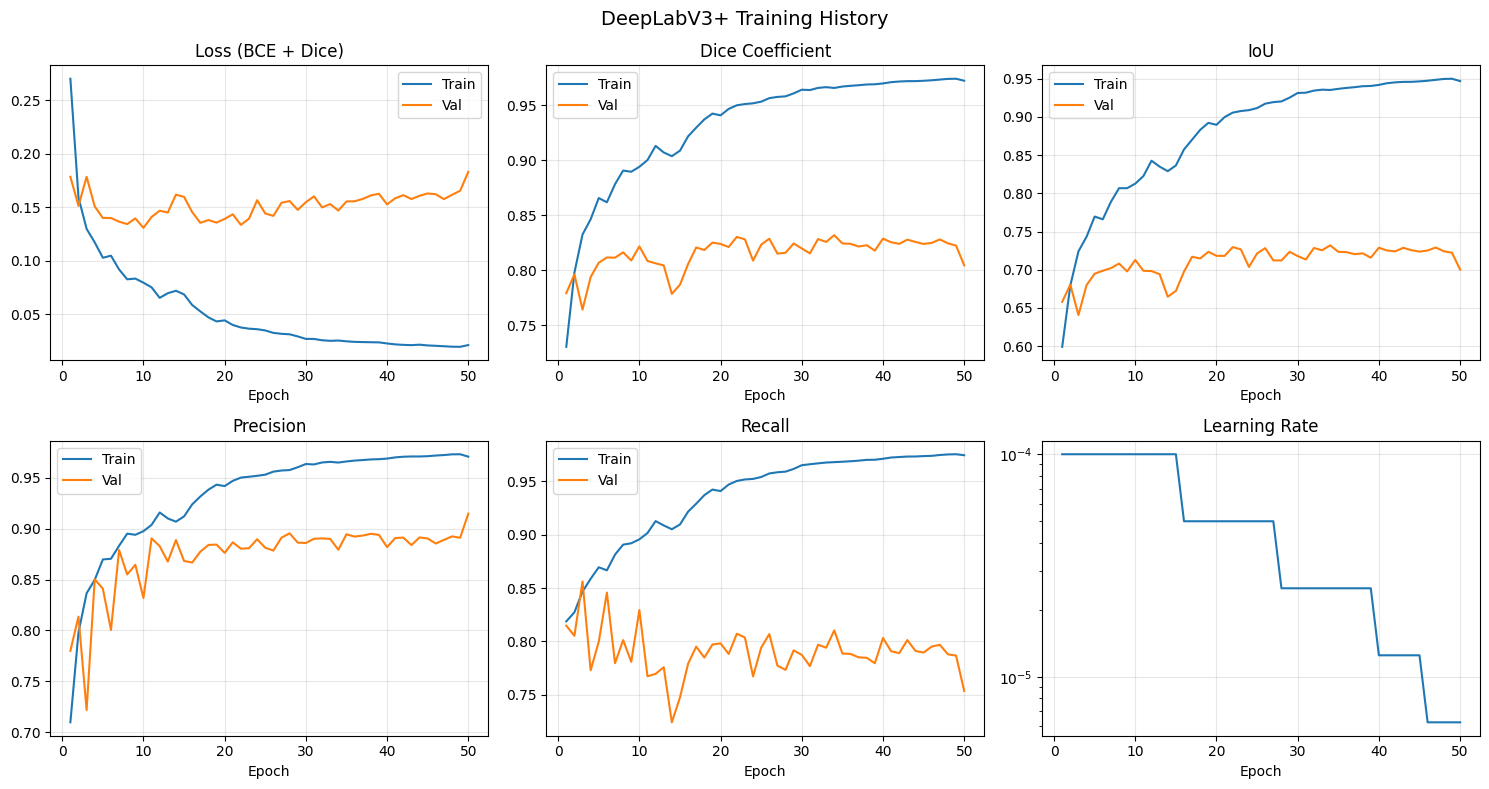


📊 Najlepsze wyniki (epoka 34):

Najlepsze wyniki (epoka 34):
   IoU:       0.7319
   Precision: 0.8794
   Recall:    0.8104


In [ ]:
import matplotlib.pyplot as plt

if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH, 'r') as f:
        history = json.load(f)
    print(f"Wczytano historie: {len(history['train_loss'])} epok")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], label='Train')
axes[0, 0].plot(epochs_range, history['val_loss'], label='Val')
axes[0, 0].set_title('Loss (BCE + Dice)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice
axes[0, 1].plot(epochs_range, history['train_dice'], label='Train')
axes[0, 1].plot(epochs_range, history['val_dice'], label='Val')
axes[0, 1].set_title('Dice Coefficient')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU
axes[0, 2].plot(epochs_range, history['train_iou'], label='Train')
axes[0, 2].plot(epochs_range, history['val_iou'], label='Val')
axes[0, 2].set_title('IoU')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(epochs_range, history['train_precision'], label='Train')
axes[1, 0].plot(epochs_range, history['val_precision'], label='Val')
axes[1, 0].set_title('Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(epochs_range, history['train_recall'], label='Train')
axes[1, 1].plot(epochs_range, history['val_recall'], label='Val')
axes[1, 1].set_title('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 2].plot(epochs_range, history['lr'])
axes[1, 2].set_title('Learning Rate')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('DeepLabV3+ Training History', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, 'training_history_deeplabv3.png'), dpi=150)
plt.show()

best_epoch = history['val_iou'].index(max(history['val_iou'])) + 1
print(f"\nNajlepsze wyniki (epoka {best_epoch}):")
print(f"\nNajlepsze wyniki (epoka {best_epoch}):")
print(f"   IoU:       {max(history['val_iou']):.4f}")
print(f"   Precision: {history['val_precision'][best_epoch-1]:.4f}")
print(f"   Recall:    {history['val_recall'][best_epoch-1]:.4f}")

EWALUACJA NA ZBIORZE TESTOWYM
Liczba probek testowych: 1680


Test: 100%|██████████| 420/420 [00:49<00:00,  8.52it/s]



📊 WYNIKI NA ZBIORZE TESTOWYM:

WYNIKI NA ZBIORZE TESTOWYM:
Dice        : 0.7704 ± 0.3399
Iou         : 0.7203 ± 0.3437
Precision   : 0.8404 ± 0.2960
Recall      : 0.8471 ± 0.2647


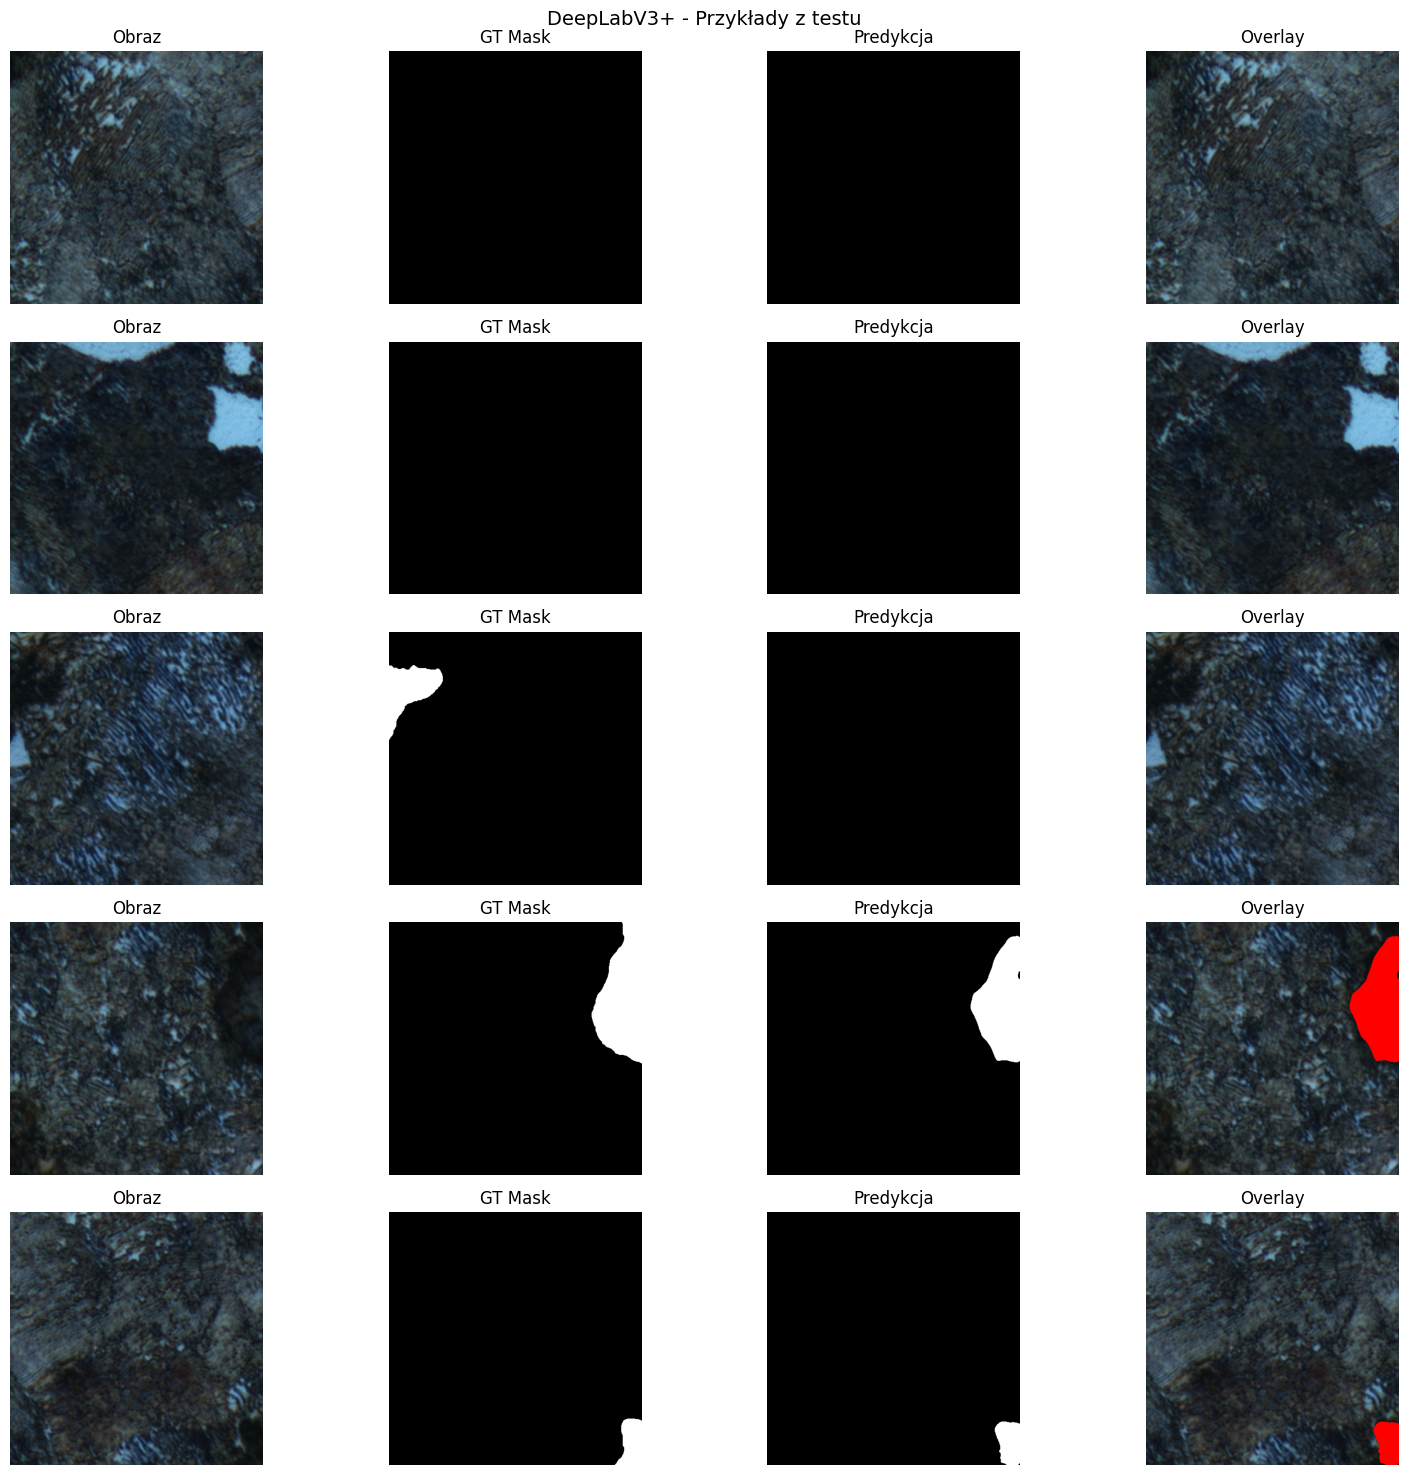

In [36]:
print("="*60)
print("EWALUACJA NA ZBIORZE TESTOWYM")
print("="*60)

# Wczytaj najlepszy model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE)['model_state_dict'])
model.eval()

test_images_path = os.path.join(SPLIT_PATH, 'test', 'images', TILED_FOLDER) # Changed DATA_PATH to SPLIT_PATH and added TILED_FOLDER
test_masks_path = os.path.join(SPLIT_PATH, 'test', 'masks', TILED_FOLDER) # Changed DATA_PATH to SPLIT_PATH and added TILED_FOLDER

# Upewnij sie, ze 'test' foldery istnieja
if not os.path.exists(test_images_path):
    print(f"Błąd: Folder z obrazami testowymi nie istnieje: {test_images_path}")
elif not os.path.exists(test_masks_path):
    print(f"Błąd: Folder z maskami testowymi nie istnieje: {test_masks_path}")
else:
    test_pairs = get_tile_pairs(test_images_path, test_masks_path)
    if len(test_pairs) == 0:
        print("Błąd: Nie znaleziono par obraz-maska w zbiorze testowym.")
    else:
        test_dataset = GraphiteDataset(test_pairs, IMG_SIZE, augment=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        print(f"Liczba probek testowych: {len(test_dataset)}")

        test_metrics = {'dice': [], 'iou': [], 'precision': [], 'recall': []}
        test_samples = []  # Do wizualizacji

        with torch.no_grad():
            for batch_idx, (images, masks) in enumerate(tqdm(test_loader, desc="Test")):
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)

                outputs = model(images)
                preds = (outputs > 0.5).float()

                # Metryki dla każdego sampla
                for i in range(images.size(0)):
                    # Uzyj wczesniej zdefiniowanych funkcji metryk
                    test_metrics['dice'].append(dice_score(outputs[i:i+1], masks[i:i+1]).item())
                    test_metrics['iou'].append(iou_score(outputs[i:i+1], masks[i:i+1]).item())
                    test_metrics['precision'].append(precision_score(outputs[i:i+1], masks[i:i+1]).item())
                    test_metrics['recall'].append(recall_score(outputs[i:i+1], masks[i:i+1]).item())

                # Zapisz kilka próbek do wizualizacji
                if batch_idx < 3:
                    for i in range(min(3, images.size(0))):
                        test_samples.append({
                            'image': images[i].cpu(),
                            'mask': masks[i].cpu(),
                            'pred': preds[i].cpu()
                        })

        print("\n📊 WYNIKI NA ZBIORZE TESTOWYM:")
        print("\nWYNIKI NA ZBIORZE TESTOWYM:")
        for metric, values in test_metrics.items():
            print(f"{metric.capitalize():12s}: {np.mean(values):.4f} \u00b1 {np.std(values):.4f}")

        # Wizualizacja przykładów
        fig, axes = plt.subplots(min(5, len(test_samples)), 4, figsize=(16, 3*min(5, len(test_samples))))

        # Odwrotna normalizacja ImageNet
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        for i, sample in enumerate(test_samples[:5]):
            # Denormalizacja obrazu
            img_denorm = sample['image'] * std + mean
            img_denorm = torch.clamp(img_denorm, 0, 1)

            axes[i, 0].imshow(img_denorm.permute(1, 2, 0).numpy())
            axes[i, 0].set_title('Obraz')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(sample['mask'].squeeze().numpy(), cmap='gray')
            axes[i, 1].set_title('GT Mask')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(sample['pred'].squeeze().numpy(), cmap='gray')
            axes[i, 2].set_title('Predykcja')
            axes[i, 2].axis('off')

            # Overlay
            overlay = img_denorm.permute(1, 2, 0).numpy().copy()
            pred_mask = sample['pred'].squeeze().numpy()
            overlay[pred_mask > 0.5] = [1, 0, 0]  # Czerwony dla predykcji
            axes[i, 3].imshow(overlay)
            axes[i, 3].set_title('Overlay')
            axes[i, 3].axis('off')

        plt.suptitle('DeepLabV3+ - Przykłady z testu', fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(MODELS_PATH, 'test_examples_deeplabv3.png'), dpi=150)
        plt.show()


In [ ]:
from PIL import Image

def predict_full_image(model, image_path, tile_size=256, overlap=32, device='cuda'):
    
    model.eval()

    # Wczytaj obraz
    image = Image.open(image_path).convert('RGB')
    img_array = np.array(image)
    h, w = img_array.shape[:2]

    # Przygotuj tensor wyjściowy
    pred_sum = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)

    stride = tile_size - overlap

    # Normalizacja ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():
        for y in range(0, h - tile_size + 1, stride):
            for x in range(0, w - tile_size + 1, stride):
                # Wytnij kafelek
                tile = img_array[y:y+tile_size, x:x+tile_size]

                # Normalizacja
                tile_norm = (tile.astype(np.float32) / 255.0 - mean) / std
                tile_tensor = torch.from_numpy(tile_norm.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

                # Predykcja
                pred = model(tile_tensor)
                pred_np = torch.sigmoid(pred).squeeze().cpu().numpy()

                # Agreguj predykcję
                pred_sum[y:y+tile_size, x:x+tile_size] += pred_np
                count_map[y:y+tile_size, x:x+tile_size] += 1

    # Uśrednij nakładające się regiony
    mask = pred_sum / np.maximum(count_map, 1)

    return (mask > 0.5).astype(np.uint8) * 255, mask

# === WIZUALIZACJA NA PRZYKLADOWYM OBRAZIE ===
full_images_dir = os.path.join(SPLIT_PATH, '..', 'full_images') # Poprawiono DATA_PATH na SPLIT_PATH

if os.path.exists(full_images_dir):
    full_images = [f for f in os.listdir(full_images_dir) if f.endswith(('.png', '.jpg', '.tif'))]

    if full_images:
        test_image = os.path.join(full_images_dir, full_images[0])
        print(f"Przetwarzanie: {test_image}")

        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE)['model_state_dict']) # Poprawiono MODEL_PATH na BEST_MODEL_PATH
        binary_mask, prob_mask = predict_full_image(model, test_image, tile_size=256, overlap=64, device=DEVICE)

        # Wizualizacja
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        original = Image.open(test_image).convert('RGB')
        axes[0].imshow(original)
        axes[0].set_title('Oryginalny obraz')
        axes[0].axis('off')

        axes[1].imshow(prob_mask, cmap='hot')
        axes[1].set_title('Mapa prawdopodobieństwa')
        axes[1].axis('off')

        axes[2].imshow(binary_mask, cmap='gray')
        axes[2].set_title('Maska binarna')
        axes[2].axis('off')

        plt.suptitle('DeepLabV3+ - Predykcja na pełnym obrazie', fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(MODELS_PATH, 'full_image_prediction_deeplabv3.png'), dpi=150)
        plt.show()

        # Zapisz maskę
        Image.fromarray(binary_mask).save(os.path.join(MODELS_PATH, 'predicted_mask_deeplabv3.png'))
        print(f"Zapisano maskę do: {os.path.join(MODELS_PATH, 'predicted_mask_deeplabv3.png')}")
else:
    print(f"Folder {full_images_dir} nie istnieje.")
    print("Aby przetestować na pełnym obrazie, utwórz folder 'full_images' z przykładowymi zdjęciami.")
    print("\nMożesz też użyć funkcji predict_full_image() bezpośrednio:")
    print("  binary_mask, prob_mask = predict_full_image(model, 'sciezka/do/obrazu.png')")

Folder /content/split/../full_images nie istnieje.
Aby przetestować na pełnym obrazie, utwórz folder 'full_images' z przykładowymi zdjęciami.

Możesz też użyć funkcji predict_full_image() bezpośrednio:
  binary_mask, prob_mask = predict_full_image(model, 'sciezka/do/obrazu.png')
